In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/robiulhasanjisan/smart-healthcare-and-lifestyle-prediction-dataset/smart_healthcare_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, roc_curve, confusion_matrix, classification_report,
                           mean_squared_error, mean_absolute_error, r2_score)
import warnings
warnings.filterwarnings('ignore')


# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# DATA LOADING & INITIAL EXPLORATION

In [3]:
df = pd.read_csv("/kaggle/input/datasets/robiulhasanjisan/smart-healthcare-and-lifestyle-prediction-dataset/smart_healthcare_dataset.csv")


## DATASET OVERVIEW

In [4]:
print(f"Shape: {df.shape}")

Shape: (5000, 16)


In [5]:
print("\nColumns:", df.columns.tolist())


Columns: ['age', 'gender', 'bmi', 'exercise_level', 'smoking', 'alcohol', 'blood_pressure', 'cholesterol', 'glucose', 'fatigue', 'chest_pain', 'dizziness', 'heart_disease', 'diabetes', 'stroke', 'health_risk_score']


In [6]:
print(f"\nData Types:\n{df.dtypes}")


Data Types:
age                    int64
gender                object
bmi                  float64
exercise_level         int64
smoking                int64
alcohol                int64
blood_pressure         int64
cholesterol            int64
glucose                int64
fatigue                int64
chest_pain             int64
dizziness              int64
heart_disease          int64
diabetes               int64
stroke                 int64
health_risk_score    float64
dtype: object


In [7]:
print(f"\nMissing Values:\n{df.isnull().sum()}")


Missing Values:
age                  0
gender               0
bmi                  0
exercise_level       0
smoking              0
alcohol              0
blood_pressure       0
cholesterol          0
glucose              0
fatigue              0
chest_pain           0
dizziness            0
heart_disease        0
diabetes             0
stroke               0
health_risk_score    0
dtype: int64


In [8]:

display(df.describe())

,age,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0
mean,48.805600,24.967800,1.005800,0.507600,0.501400,134.445400,224.616400,134.497400,0.515200,0.504000,0.497400,0.299800,0.349200,0.248600,100.0
std,17.906991,4.960379,0.815291,0.499992,0.500048,26.191438,43.129773,37.437028,0.499819,0.500034,0.500043,0.458216,0.476765,0.432245,0.0
min,18.000000,15.000000,0.000000,0.000000,0.000000,90.000000,150.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
25%,34.000000,21.500000,0.000000,0.000000,0.000000,111.000000,187.000000,102.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
50%,49.000000,24.900000,1.000000,1.000000,1.000000,134.000000,226.000000,134.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,100.0
75%,64.000000,28.400000,2.000000,1.000000,1.000000,157.000000,262.000000,167.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,100.0
max,79.000000,42.600000,2.000000,1.000000,1.000000,179.000000,299.000000,199.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.0


In [9]:
display(df.head())

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


In [10]:
display(df.tail())

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
4995,42,Female,15.3,2,1,1,92,292,121,0,1,1,0,0,0,100.0
4996,39,Female,24.2,0,1,1,140,156,83,0,0,0,0,0,0,100.0
4997,48,Female,19.2,2,0,0,135,247,89,1,1,1,0,0,0,100.0
4998,34,Male,24.0,0,1,1,144,254,187,1,1,1,0,0,0,100.0
4999,72,Female,29.9,1,0,1,115,179,121,1,0,0,1,1,1,100.0


# EDA

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Target + Categorical Distributions
###  Target Distribution - Heart Disease
###  Diabetes Distribution
###  Stroke Distribution
###  Gender Distribution

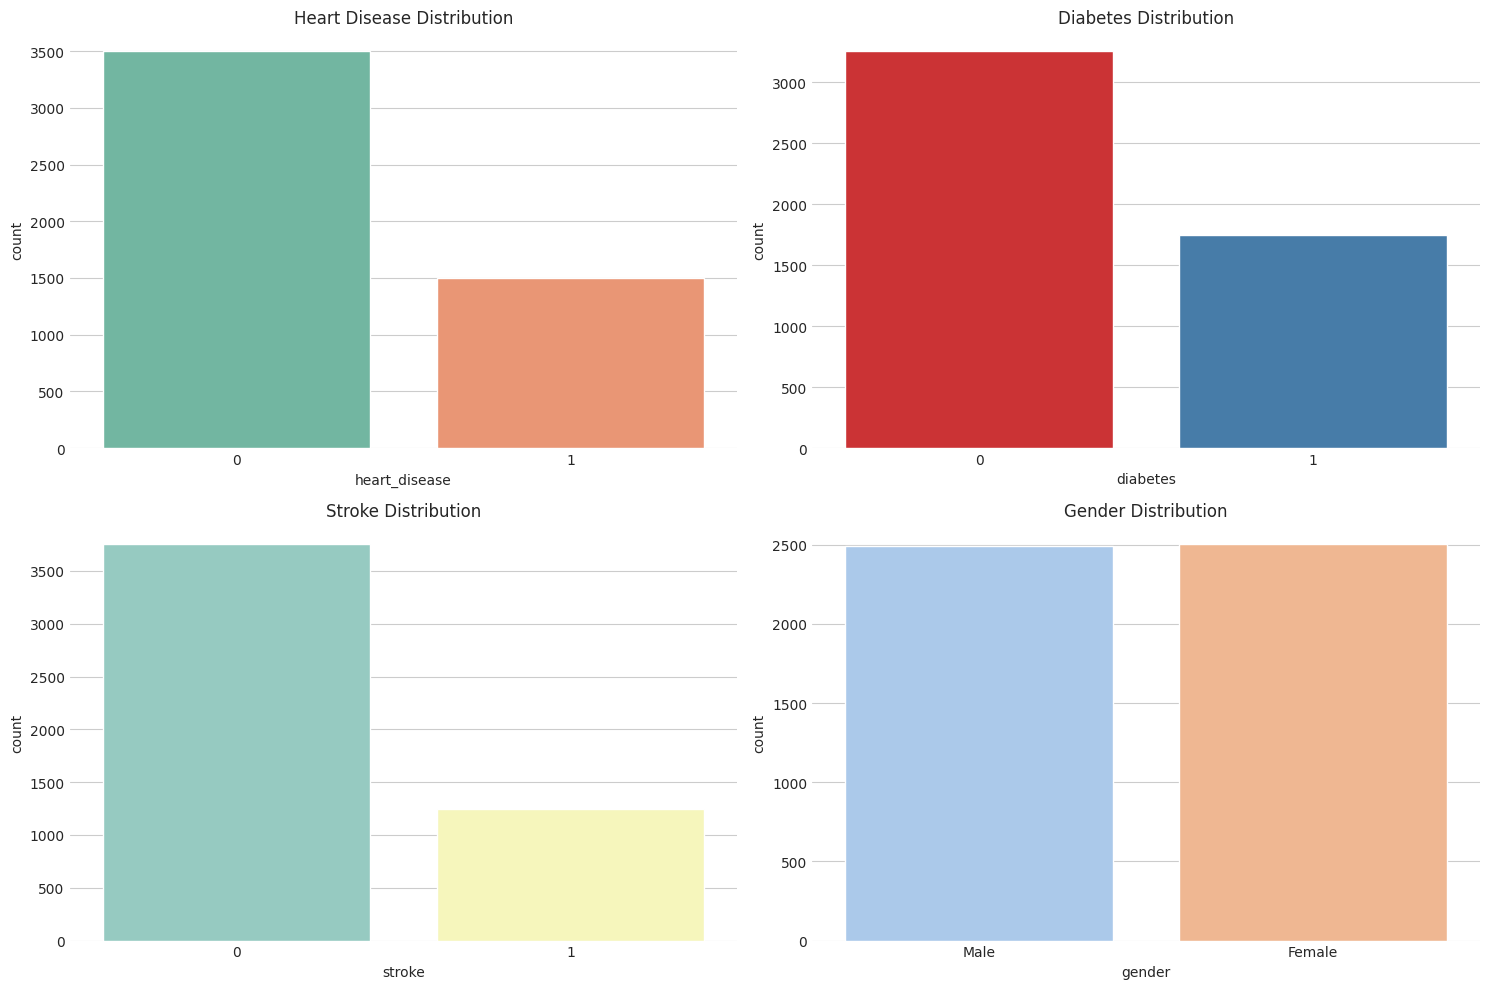

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x='heart_disease', ax=axes[0,0], palette='Set2')
axes[0,0].set_title("Heart Disease Distribution")

sns.countplot(data=df, x='diabetes', ax=axes[0,1], palette='Set1')
axes[0,1].set_title("Diabetes Distribution")

sns.countplot(data=df, x='stroke', ax=axes[1,0], palette='Set3')
axes[1,0].set_title("Stroke Distribution")

sns.countplot(data=df, x='gender', ax=axes[1,1], palette='pastel')
axes[1,1].set_title("Gender Distribution")

plt.tight_layout()
plt.show()

## Key Numeric Distributions


###  Cholesterol Distribution
###  Blood Pressure Distribution
###  BMI Distribution
###  Age Distribution with KDE

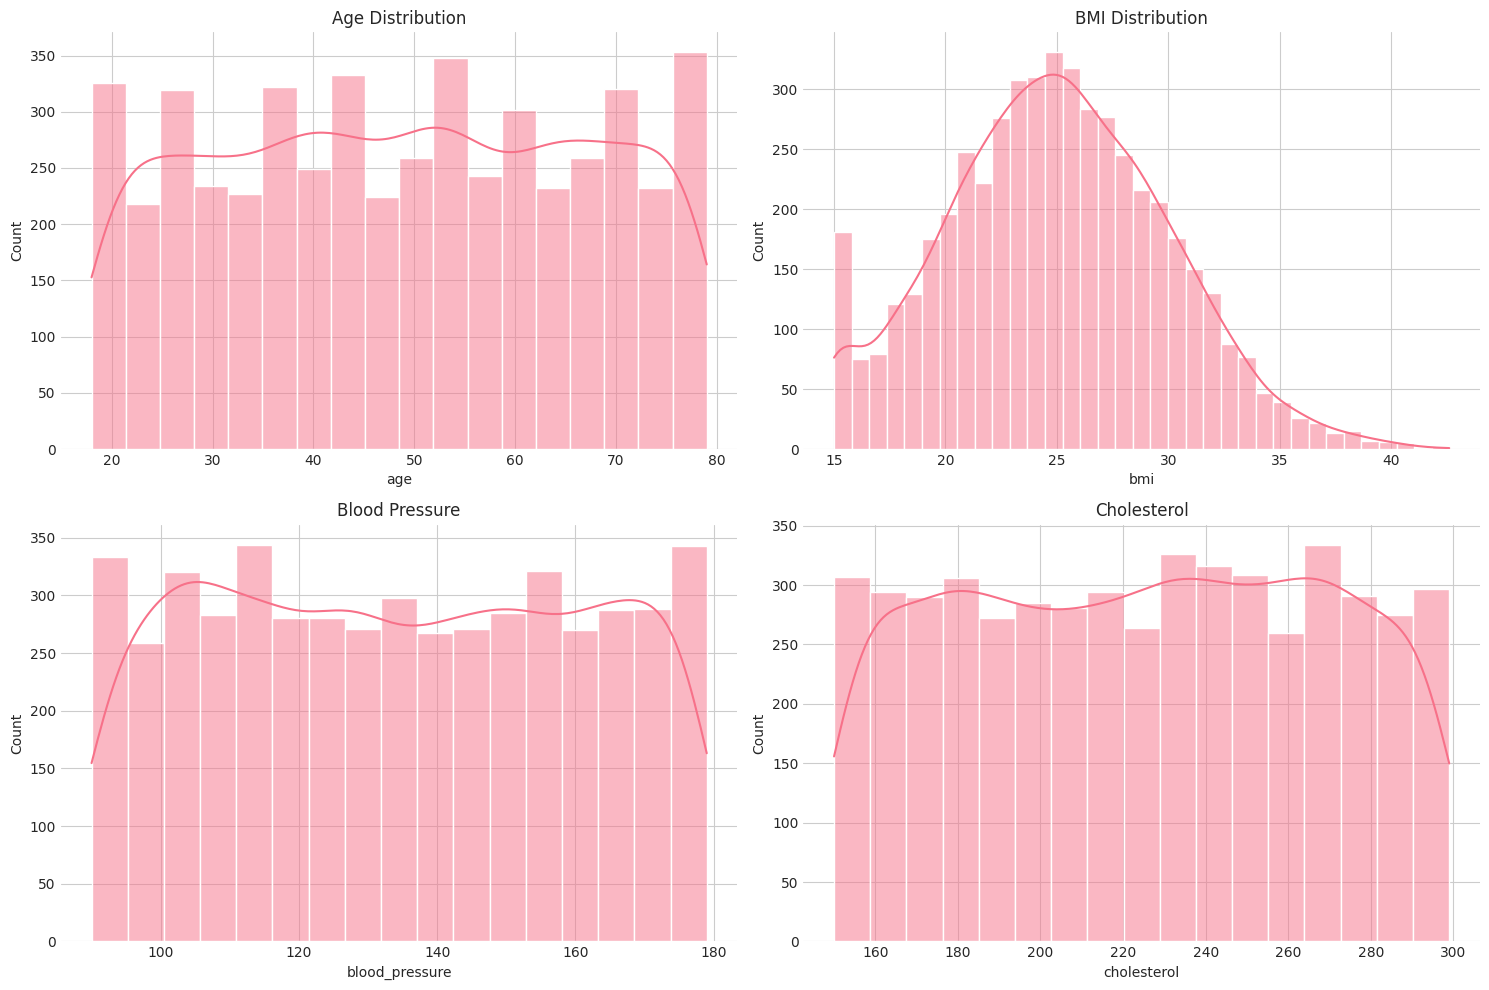

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['age'], kde=True, ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

sns.histplot(df['bmi'], kde=True, ax=axes[0,1])
axes[0,1].set_title("BMI Distribution")

sns.histplot(df['blood_pressure'], kde=True, ax=axes[1,0])
axes[1,0].set_title("Blood Pressure")

sns.histplot(df['cholesterol'], kde=True, ax=axes[1,1])
axes[1,1].set_title("Cholesterol")

plt.tight_layout()
plt.show()

## Health Risk Features

###  Glucose Distribution
###  Health Risk Score Distribution

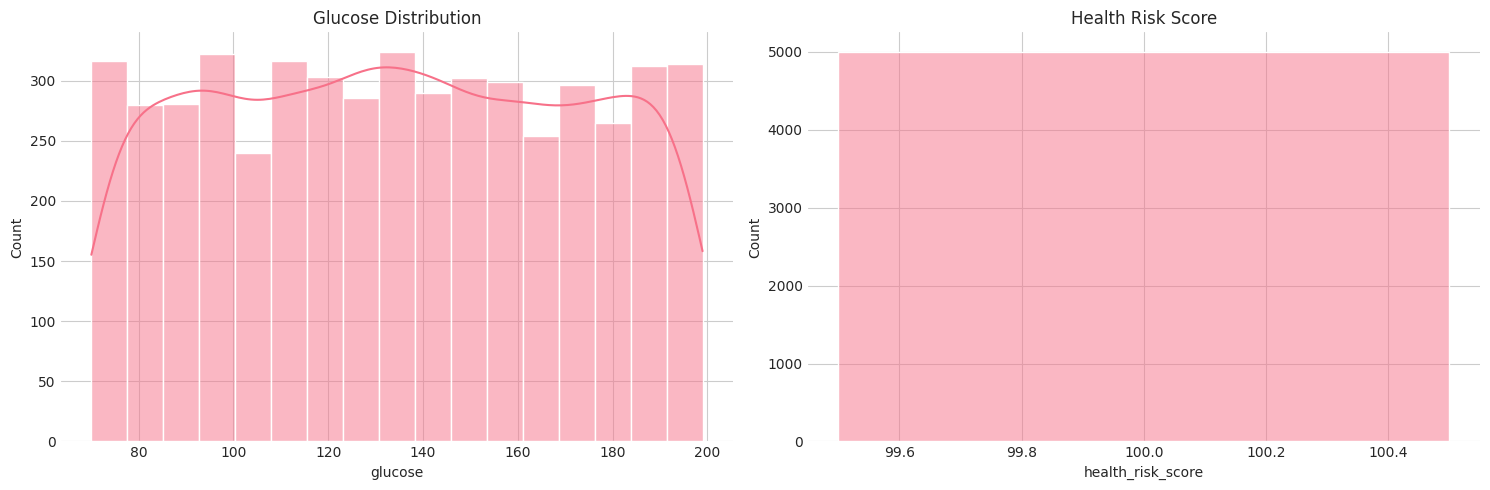

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['glucose'], kde=True, ax=axes[0])
axes[0].set_title("Glucose Distribution")

sns.histplot(df['health_risk_score'], kde=True, ax=axes[1])
axes[1].set_title("Health Risk Score")

plt.tight_layout()
plt.show()

## Medical Relationships

###  Boxplot - Age vs Heart Disease
###  Boxplot - BMI vs Diabetes
###  Boxplot - Glucose vs Diabetes
###  Boxplot - Cholesterol vs Heart Disease

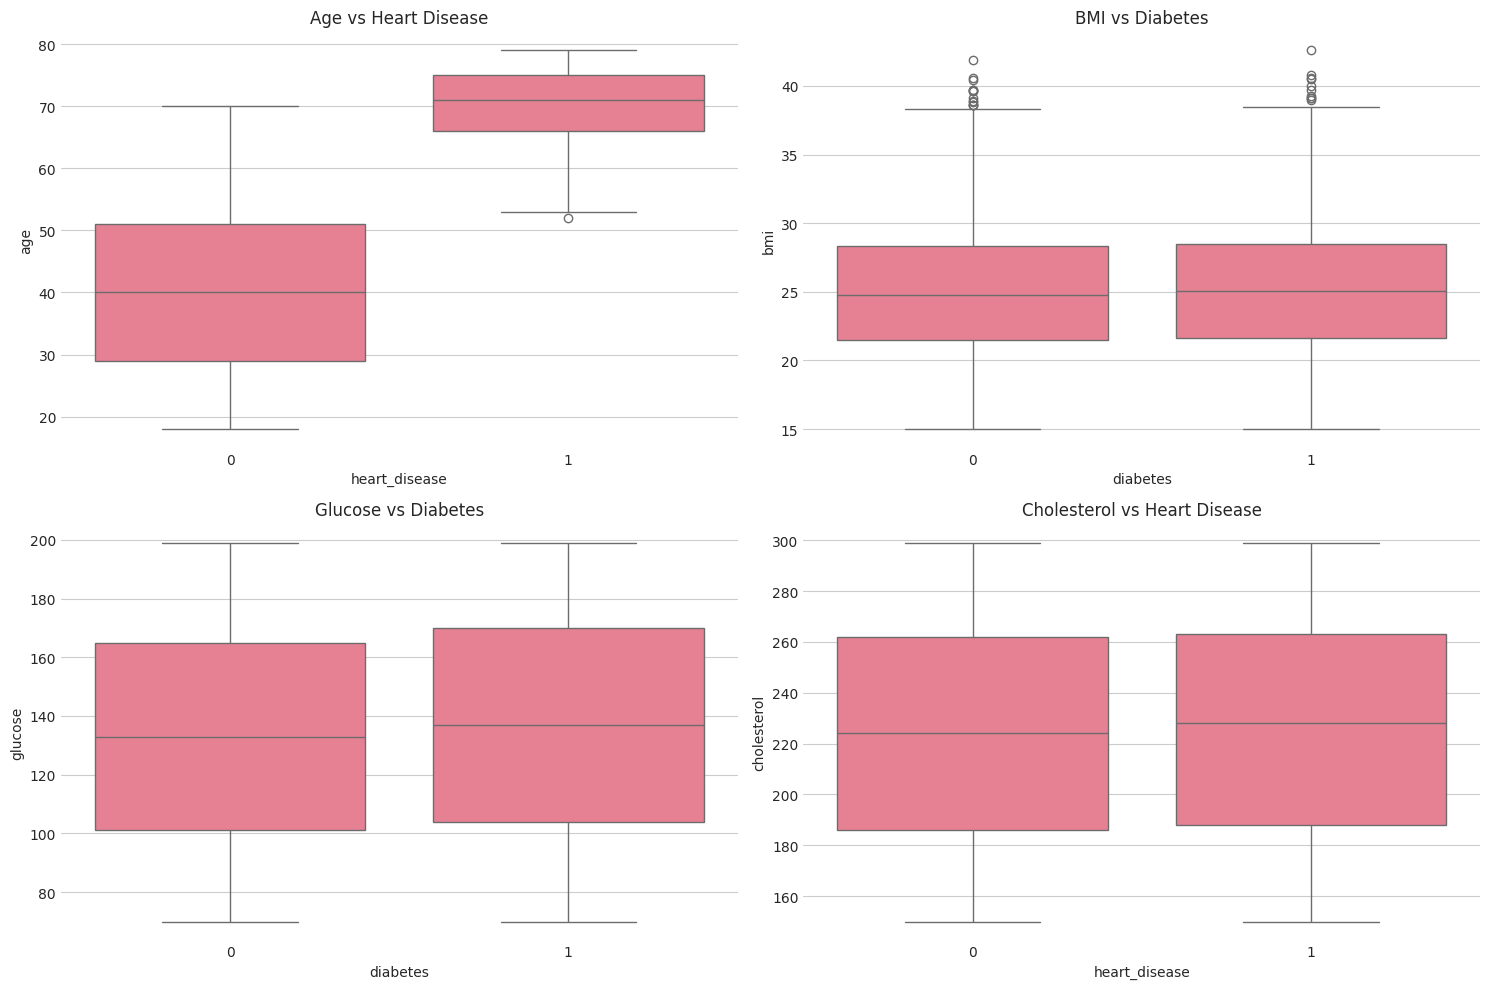

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=df, x='heart_disease', y='age', ax=axes[0,0])
axes[0,0].set_title("Age vs Heart Disease")

sns.boxplot(data=df, x='diabetes', y='bmi', ax=axes[0,1])
axes[0,1].set_title("BMI vs Diabetes")

sns.boxplot(data=df, x='diabetes', y='glucose', ax=axes[1,0])
axes[1,0].set_title("Glucose vs Diabetes")

sns.boxplot(data=df, x='heart_disease', y='cholesterol', ax=axes[1,1])
axes[1,1].set_title("Cholesterol vs Heart Disease")

plt.tight_layout()
plt.show()

## Behavioral Impact

### Smoking Impact on Heart Disease
### Exercise Level vs Health Ris

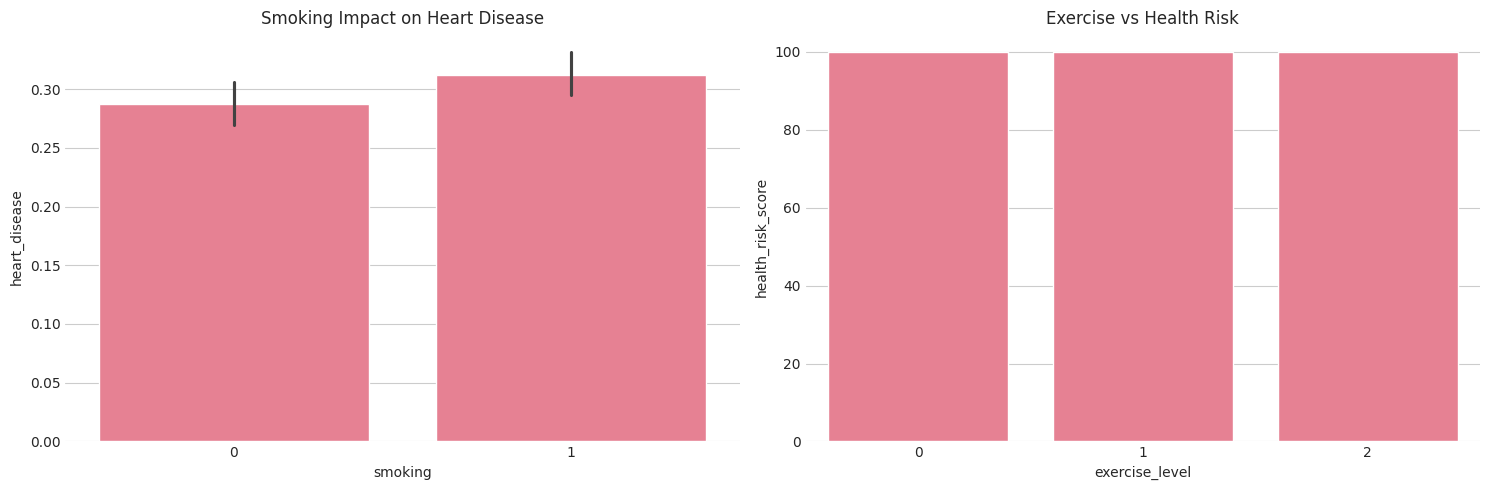

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=df, x='smoking', y='heart_disease', ax=axes[0])
axes[0].set_title("Smoking Impact on Heart Disease")

sns.barplot(data=df, x='exercise_level', y='health_risk_score', ax=axes[1])
axes[1].set_title("Exercise vs Health Risk")

plt.tight_layout()
plt.show()

## Correlation Heatmap

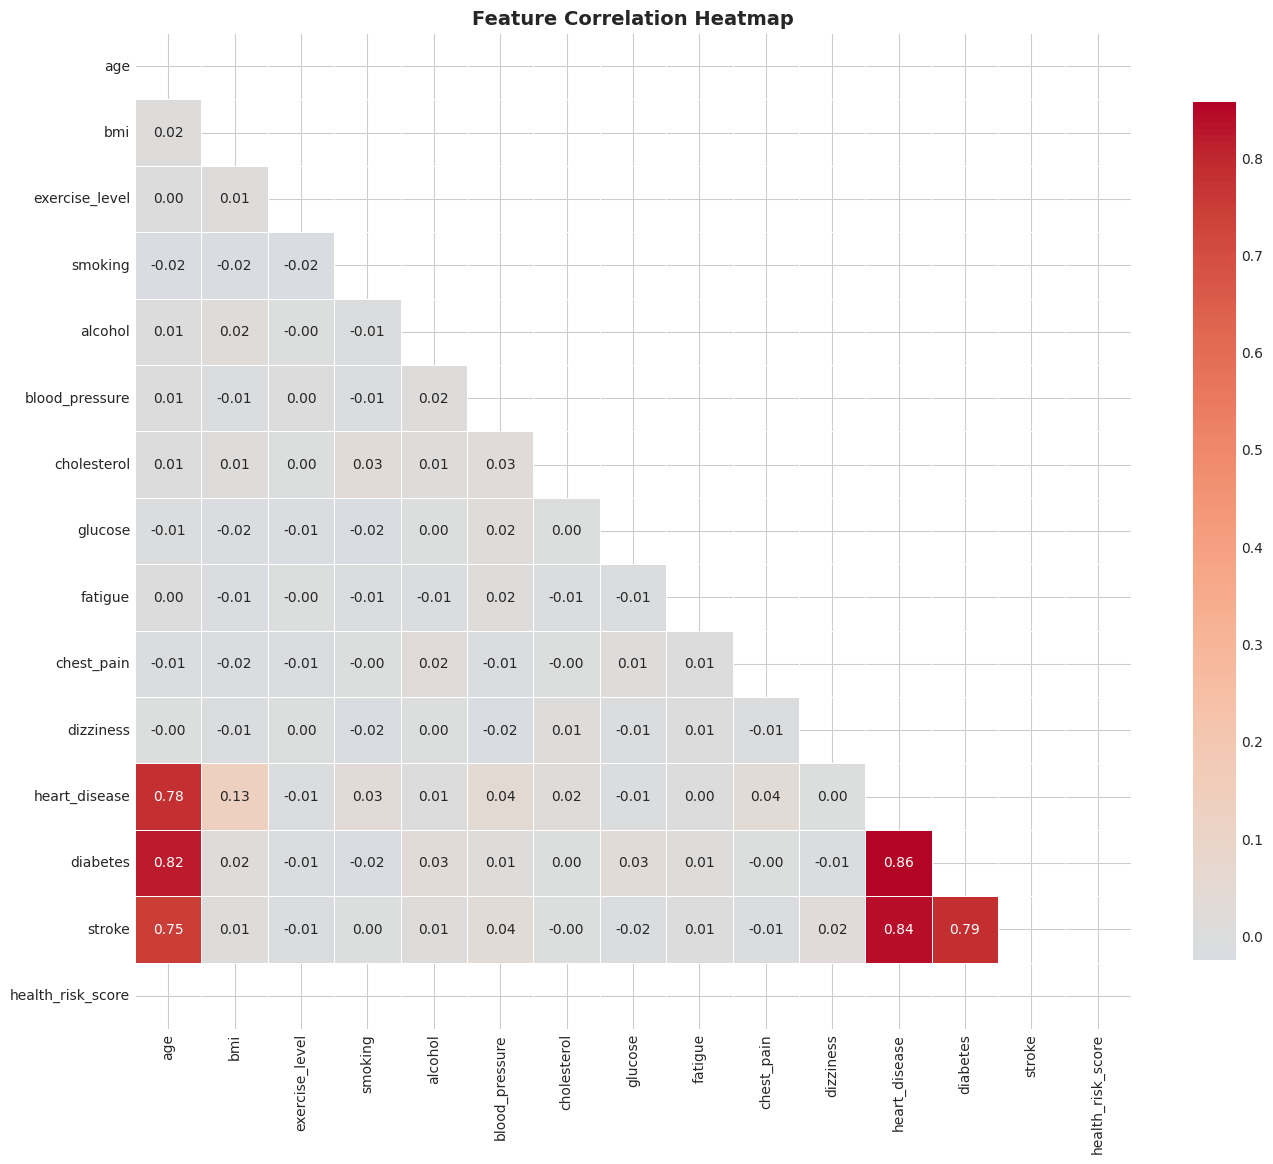

In [17]:
plt.figure(figsize=(14, 12))

correlation_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Pairplot

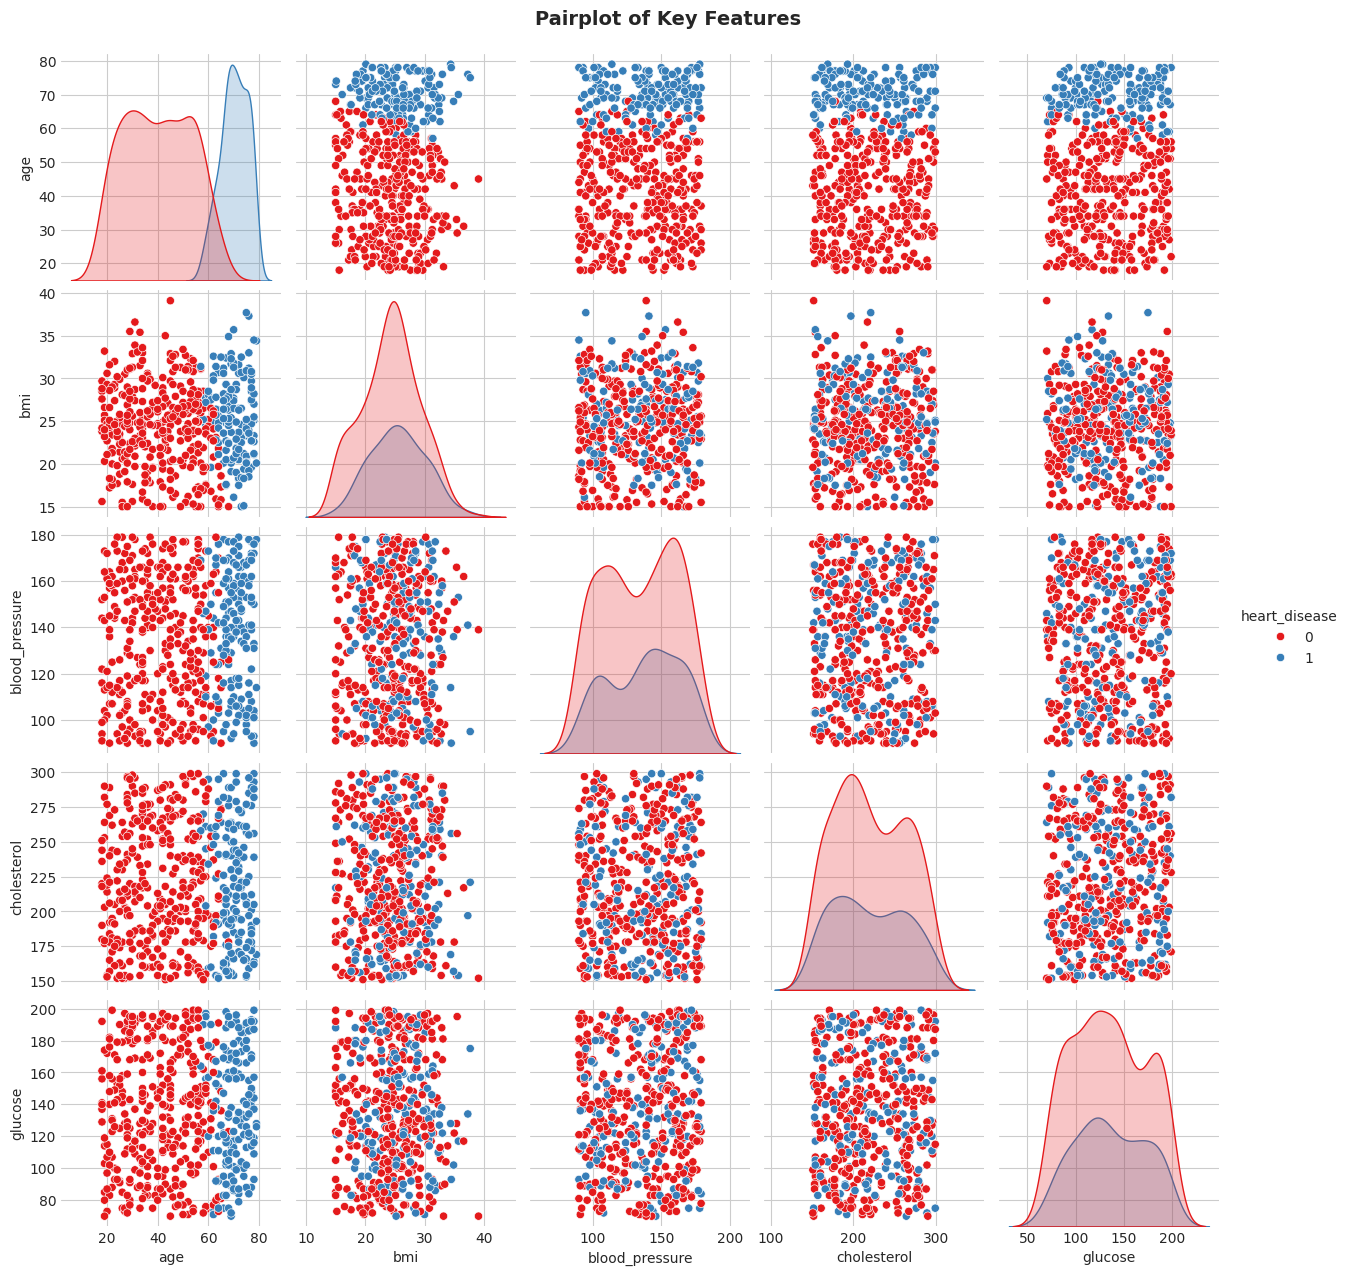

In [18]:
important_features = [
    'age', 'bmi', 'blood_pressure',
    'cholesterol', 'glucose', 'heart_disease'
]

sns.pairplot(
    df[important_features].sample(min(500, len(df))),
    hue='heart_disease',
    palette='Set1',
    diag_kind='kde'
)

plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## Distribution Insight

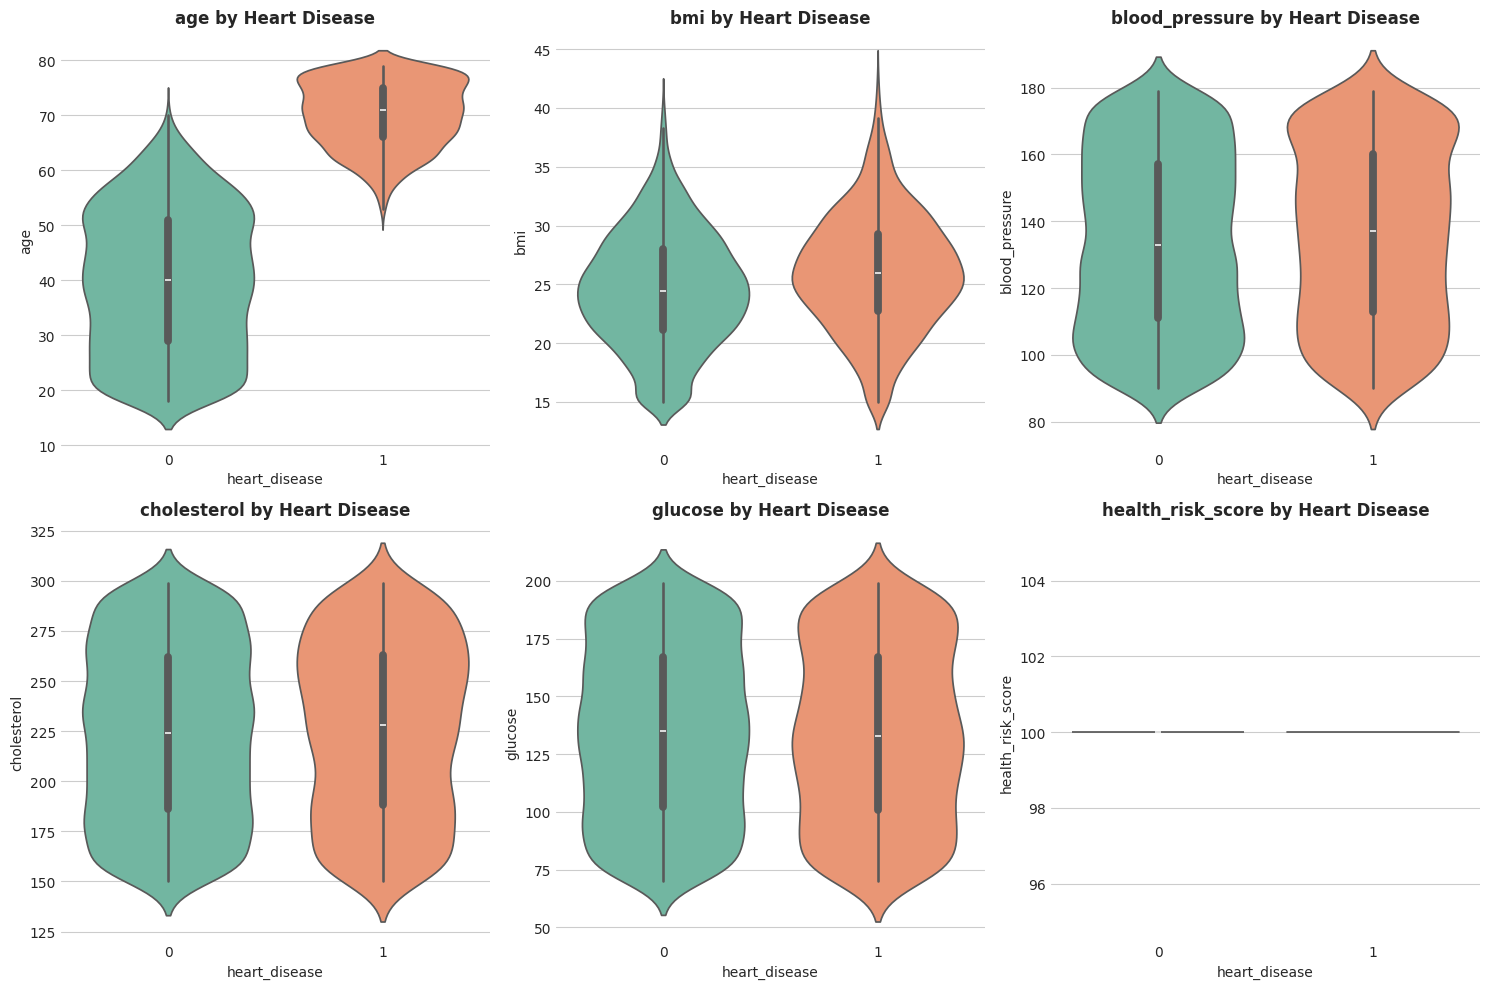

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features_violin = [
    'age', 'bmi', 'blood_pressure',
    'cholesterol', 'glucose', 'health_risk_score'
]

for i, feature in enumerate(features_violin):
    row, col = i // 3, i % 3
    sns.violinplot(
        data=df,
        x='heart_disease',
        y=feature,
        ax=axes[row, col],
        palette='Set2'
    )
    axes[row, col].set_title(f'{feature} by Heart Disease', fontweight='bold')

plt.tight_layout()
plt.show()

## Multi-Disease Risk Comparison

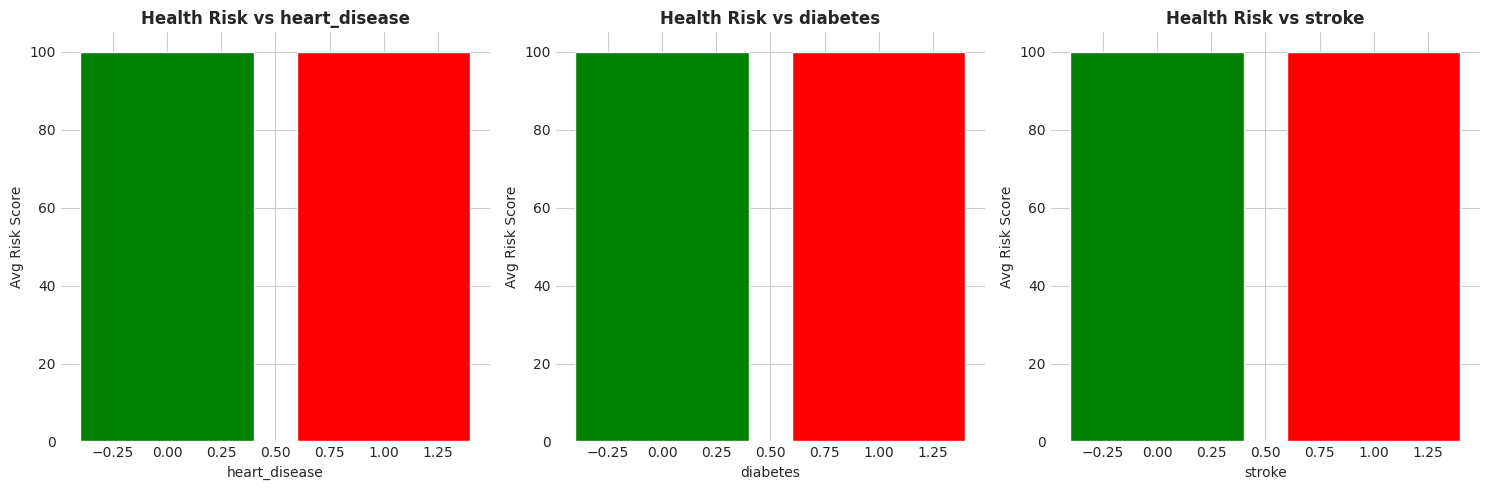

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

targets = ['heart_disease', 'diabetes', 'stroke']

for i, target in enumerate(targets):
    df_grouped = df.groupby(target)['health_risk_score'].mean()

    axes[i].bar(df_grouped.index, df_grouped.values, color=['green', 'red'])
    axes[i].set_title(f'Health Risk vs {target}', fontweight='bold')
    axes[i].set_xlabel(target)
    axes[i].set_ylabel('Avg Risk Score')

plt.tight_layout()
plt.show()

## Lifestyle Correlation Heatmap

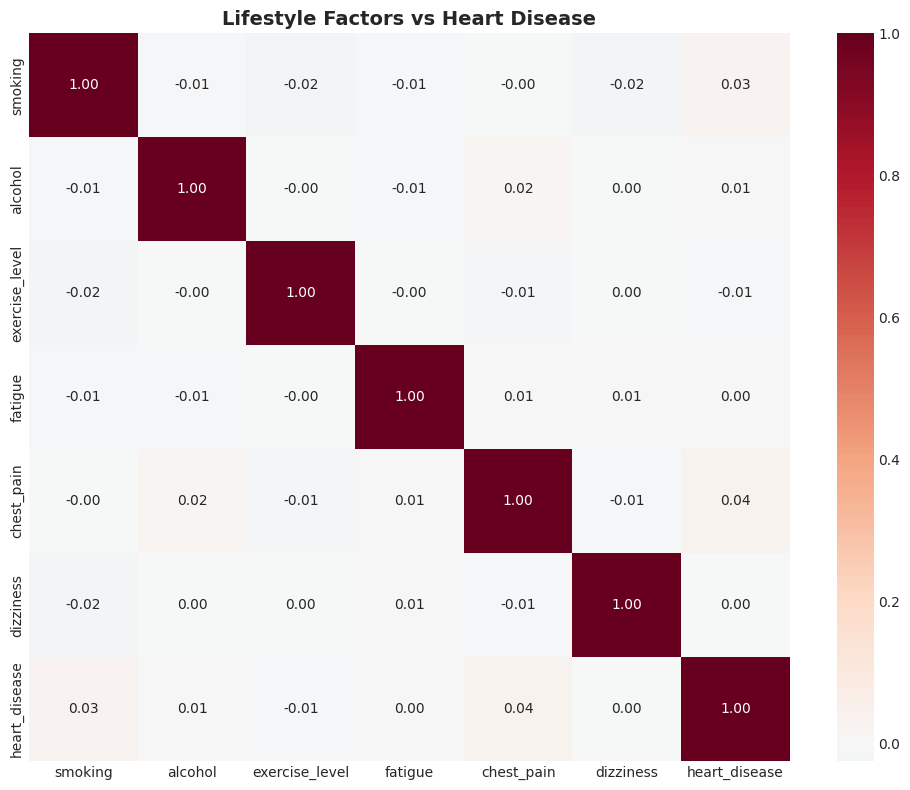

In [21]:
lifestyle_factors = [
    'smoking', 'alcohol', 'exercise_level',
    'fatigue', 'chest_pain', 'dizziness'
]

lifestyle_corr = df[lifestyle_factors + ['heart_disease']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(lifestyle_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)

plt.title('Lifestyle Factors vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Age Group Disease Analysis

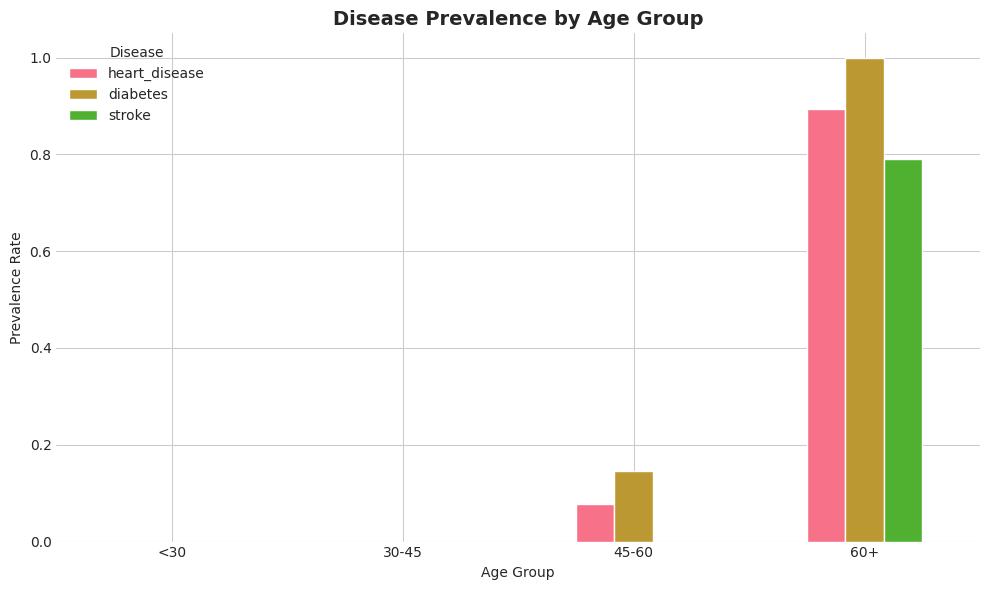

In [22]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 100],
    labels=['<30', '30-45', '45-60', '60+']
)

age_group_analysis = df.groupby('age_group')[['heart_disease', 'diabetes', 'stroke']].mean()

age_group_analysis.plot(kind='bar', figsize=(10, 6))

plt.title('Disease Prevalence by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Prevalence Rate')
plt.xticks(rotation=0)
plt.legend(title='Disease')

plt.tight_layout()
plt.show()

#  DATA PREPROCESSING

In [23]:



# Encode categorical variables
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

# Create age groups feature
df['age_group_encoded'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100], labels=[0, 1, 2, 3])

# Create BMI categories
def bmi_category(bmi):
    if bmi < 18.5:
        return 0  # Underweight
    elif bmi < 25:
        return 1  # Normal
    elif bmi < 30:
        return 2  # Overweight
    else:
        return 3  # Obese

df['bmi_category'] = df['bmi'].apply(bmi_category)

# Create blood pressure categories
def bp_category(bp):
    if bp < 120:
        return 0  # Normal
    elif bp < 140:
        return 1  # Elevated
    else:
        return 2  # High

df['bp_category'] = df['blood_pressure'].apply(bp_category)

# Define features and targets
X = df.drop(['heart_disease', 'diabetes', 'stroke', 'health_risk_score', 
             'age_group', 'age_group_encoded', 'bmi_category', 'bp_category'], axis=1)

# Binary classification targets
y_heart = df['heart_disease']
y_diabetes = df['diabetes']
y_stroke = df['stroke']

# Multi-label target
y_multilabel = df[['heart_disease', 'diabetes', 'stroke']]

# Regression target
y_regression = df['health_risk_score']



In [24]:
print(f"Features shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")


Features shape: (5000, 12)
Features: ['age', 'gender', 'bmi', 'exercise_level', 'smoking', 'alcohol', 'blood_pressure', 'cholesterol', 'glucose', 'fatigue', 'chest_pain', 'dizziness']


## Split data

In [25]:

# Split data for classification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

# Split for multilabel
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X, y_multilabel, test_size=0.2, random_state=42
)

# Split for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=42
)

# Scaling
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

# Apply StandardScaler to all splits
X_train_scaled = scaler_standard.fit_transform(X_train)
X_test_scaled = scaler_standard.transform(X_test)
X_train_ml_scaled = scaler_standard.fit_transform(X_train_ml)
X_test_ml_scaled = scaler_standard.transform(X_test_ml)
X_train_reg_scaled = scaler_standard.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_standard.transform(X_test_reg)


# SUPERVISED CLASSIFICATION MODELS

In [26]:


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                              AdaBoostClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [27]:

# Dictionary of all classification models
classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'MLP Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(n_estimators=100, verbose=0, random_state=42)
}

# Train and evaluate all models
classification_results = []


print("CLASSIFICATION MODEL COMPARISON (Heart Disease Prediction)")


for name, model in classification_models.items():
    try:
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Predictions
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
        
        classification_results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': auc,
            'CV Mean F1': cv_scores.mean(),
            'CV Std F1': cv_scores.std()
        })
        
        print(f"\n{name}:")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  ROC-AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"\n{name}: Error - {str(e)}")

# Convert results to DataFrame
classification_df = pd.DataFrame(classification_results)
classification_df = classification_df.sort_values('F1-Score', ascending=False)



display(classification_df)


CLASSIFICATION MODEL COMPARISON (Heart Disease Prediction)

Logistic Regression:
  Accuracy: 0.9940
  F1-Score: 0.9900
  ROC-AUC: 0.9998

Decision Tree:
  Accuracy: 0.9690
  F1-Score: 0.9484
  ROC-AUC: 0.9636

Random Forest:
  Accuracy: 0.9670
  F1-Score: 0.9447
  ROC-AUC: 0.9960

Gradient Boosting:
  Accuracy: 0.9860
  F1-Score: 0.9767
  ROC-AUC: 0.9986

AdaBoost:
  Accuracy: 0.9890
  F1-Score: 0.9815
  ROC-AUC: 0.9993

Extra Trees:
  Accuracy: 0.9630
  F1-Score: 0.9368
  ROC-AUC: 0.9957

SVM:
  Accuracy: 0.9760
  F1-Score: 0.9596
  ROC-AUC: 0.9983

KNN:
  Accuracy: 0.8590
  F1-Score: 0.7478
  ROC-AUC: 0.9190

Naive Bayes:
  Accuracy: 0.9490
  F1-Score: 0.9157
  ROC-AUC: 0.9916

MLP Neural Network:
  Accuracy: 0.9900
  F1-Score: 0.9834
  ROC-AUC: 0.9995

XGBoost:
  Accuracy: 0.9850
  F1-Score: 0.9750
  ROC-AUC: 0.9992

LightGBM:
  Accuracy: 0.9840
  F1-Score: 0.9734
  ROC-AUC: 0.9988

CatBoost:
  Accuracy: 0.9870
  F1-Score: 0.9782
  ROC-AUC: 0.9992


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Mean F1,CV Std F1
0,Logistic Regression,0.994,0.993289,0.986667,0.989967,0.999781,0.984553,0.003918
9,MLP Neural Network,0.990,0.976974,0.990000,0.983444,0.999510,0.974496,0.005517
4,AdaBoost,0.989,0.989831,0.973333,0.981513,0.999252,0.984596,0.003759
12,CatBoost,0.987,0.983165,0.973333,0.978224,0.999195,0.973641,0.008273
3,Gradient Boosting,0.986,0.976667,0.976667,0.976667,0.998621,0.974075,0.007055
10,XGBoost,0.985,0.976589,0.973333,0.974958,0.999186,0.974077,0.006627
11,LightGBM,0.984,0.970199,0.976667,0.973422,0.998781,0.972736,0.008207
6,SVM,0.976,0.969388,0.950000,0.959596,0.998262,0.957046,0.007982
1,Decision Tree,0.969,0.946844,0.950000,0.948419,0.963571,0.948908,0.009121
2,Random Forest,0.967,0.949495,0.940000,0.944724,0.996000,0.958965,0.008271


#  BEST CLASSIFICATION MODEL DETAILED ANALYSIS

DETAILED ANALYSIS - BEST MODEL: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.99      1.00      1.00       700
     Disease       0.99      0.99      0.99       300

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



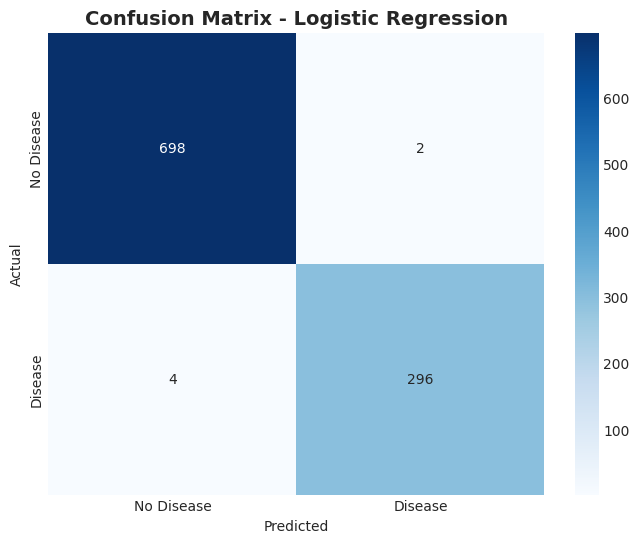

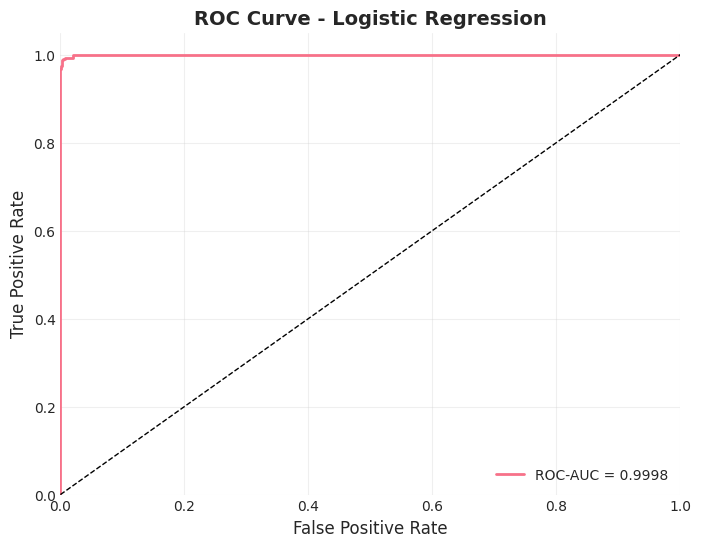

In [28]:



best_classifier_name = classification_df.iloc[0]['Model']
best_classifier = classification_models[best_classifier_name]
best_classifier.fit(X_train_scaled, y_train)
y_pred_best = best_classifier.predict(X_test_scaled)
y_pred_proba_best = best_classifier.predict_proba(X_test_scaled)[:, 1]


print(f"DETAILED ANALYSIS - BEST MODEL: {best_classifier_name}")


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Disease', 'Disease']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix - {best_classifier_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {roc_auc_score(y_test, y_pred_proba_best):.4f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {best_classifier_name}', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


#  MULTI-LABEL CLASSIFICATION

In [29]:

from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, roc_auc_score


In [30]:
# Prepare multi-label models
multilabel_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

multilabel_results = []


print("MULTI-LABEL CLASSIFICATION RESULTS")


for name, model in multilabel_models.items():
    multi_model = MultiOutputClassifier(model)
    multi_model.fit(X_train_ml_scaled, y_train_ml)
    
    y_pred_ml = multi_model.predict(X_test_ml_scaled)
    y_pred_proba_ml = multi_model.predict_proba(X_test_ml_scaled)
    
    results_dict = {'Model': name}
    
    for i, col in enumerate(y_multilabel.columns):
        f1 = f1_score(y_test_ml.iloc[:, i], y_pred_ml[:, i])
        auc = roc_auc_score(y_test_ml.iloc[:, i], y_pred_proba_ml[i][:, 1])
        results_dict[f'{col}_F1'] = f1
        results_dict[f'{col}_AUC'] = auc
    
    multilabel_results.append(results_dict)
    print(f"\n{name}:")
    for i, col in enumerate(y_multilabel.columns):
        print(f"  {col} - F1: {results_dict[f'{col}_F1']:.4f}, AUC: {results_dict[f'{col}_AUC']:.4f}")

multilabel_df = pd.DataFrame(multilabel_results)
print("\nMulti-label Results Summary:")
display(multilabel_df)


MULTI-LABEL CLASSIFICATION RESULTS

Random Forest:
  heart_disease - F1: 0.9709, AUC: 0.9984
  diabetes - F1: 0.9831, AUC: 0.9997
  stroke - F1: 0.9780, AUC: 0.9998

XGBoost:
  heart_disease - F1: 0.9806, AUC: 0.9993
  diabetes - F1: 0.9972, AUC: 0.9999
  stroke - F1: 0.9960, AUC: 1.0000

LightGBM:
  heart_disease - F1: 0.9806, AUC: 0.9991
  diabetes - F1: 0.9943, AUC: 0.9999
  stroke - F1: 0.9940, AUC: 1.0000

Multi-label Results Summary:


,Model,heart_disease_F1,heart_disease_AUC,diabetes_F1,diabetes_AUC,stroke_F1,stroke_AUC
0,Random Forest,0.970874,0.998378,0.983099,0.999679,0.977956,0.999777
1,XGBoost,0.980645,0.999261,0.997167,0.999943,0.995984,0.999995
2,LightGBM,0.980645,0.999135,0.994334,0.999917,0.993964,0.999968


#  ALL SUPERVISED REGRESSION MODELS

In [31]:


from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                              AdaBoostRegressor, ExtraTreesRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [32]:

# Dictionary of all regression models
regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost Regressor': AdaBoostRegressor(n_estimators=100, random_state=42),
    'Extra Trees Regressor': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf'),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, random_state=42),
    'LightGBM Regressor': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    'CatBoost Regressor': CatBoostRegressor(n_estimators=100, verbose=0, random_state=42)
}

# Train and evaluate all regression models
regression_results = []


print("REGRESSION MODEL COMPARISON (Health Risk Score Prediction)")


for name, model in regression_models.items():
    try:
        # Train model
        model.fit(X_train_reg_scaled, y_train_reg)
        
        # Predictions
        y_pred_reg = model.predict(X_test_reg_scaled)
        
        # Metrics
        mse = mean_squared_error(y_test_reg, y_pred_reg)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test_reg, y_pred_reg)
        r2 = r2_score(y_test_reg, y_pred_reg)
        
        # Cross-validation
        cv_scores = cross_val_score(model, X_train_reg_scaled, y_train_reg, cv=5, scoring='r2')
        
        regression_results.append({
            'Model': name,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R² Score': r2,
            'CV Mean R²': cv_scores.mean(),
            'CV Std R²': cv_scores.std()
        })
        
        print(f"\n{name}:")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE: {mae:.4f}")
        print(f"  R² Score: {r2:.4f}")
        
    except Exception as e:
        print(f"\n{name}: Error - {str(e)}")

# Convert results to DataFrame
regression_df = pd.DataFrame(regression_results)
regression_df = regression_df.sort_values('R² Score', ascending=False)


print("REGRESSION MODELS RANKING (by R² Score)")

display(regression_df)


REGRESSION MODEL COMPARISON (Health Risk Score Prediction)

Linear Regression:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

Ridge Regression:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

Lasso Regression:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

ElasticNet:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

Decision Tree Regressor:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

Random Forest Regressor:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

Gradient Boosting Regressor:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

AdaBoost Regressor:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

Extra Trees Regressor:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

SVR:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

KNN Regressor:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

XGBoost Regressor:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

LightGBM Regressor:
  RMSE: 0.0000
  MAE: 0.0000
  R² Score: 1.0000

CatBoost Regressor: Error - catboost/libs/metrics/metri

,Model,MSE,RMSE,MAE,R² Score,CV Mean R²,CV Std R²
0,Linear Regression,0.0,0.0,0.0,1.0,1.0,0.0
1,Ridge Regression,0.0,0.0,0.0,1.0,1.0,0.0
2,Lasso Regression,0.0,0.0,0.0,1.0,1.0,0.0
3,ElasticNet,0.0,0.0,0.0,1.0,1.0,0.0
4,Decision Tree Regressor,0.0,0.0,0.0,1.0,1.0,0.0
5,Random Forest Regressor,0.0,0.0,0.0,1.0,1.0,0.0
6,Gradient Boosting Regressor,0.0,0.0,0.0,1.0,1.0,0.0
7,AdaBoost Regressor,0.0,0.0,0.0,1.0,1.0,0.0
8,Extra Trees Regressor,0.0,0.0,0.0,1.0,1.0,0.0
9,SVR,0.0,0.0,0.0,1.0,1.0,0.0


#  BEST REGRESSION MODEL DETAILED ANALYSIS

DETAILED ANALYSIS - BEST REGRESSION MODEL: Linear Regression


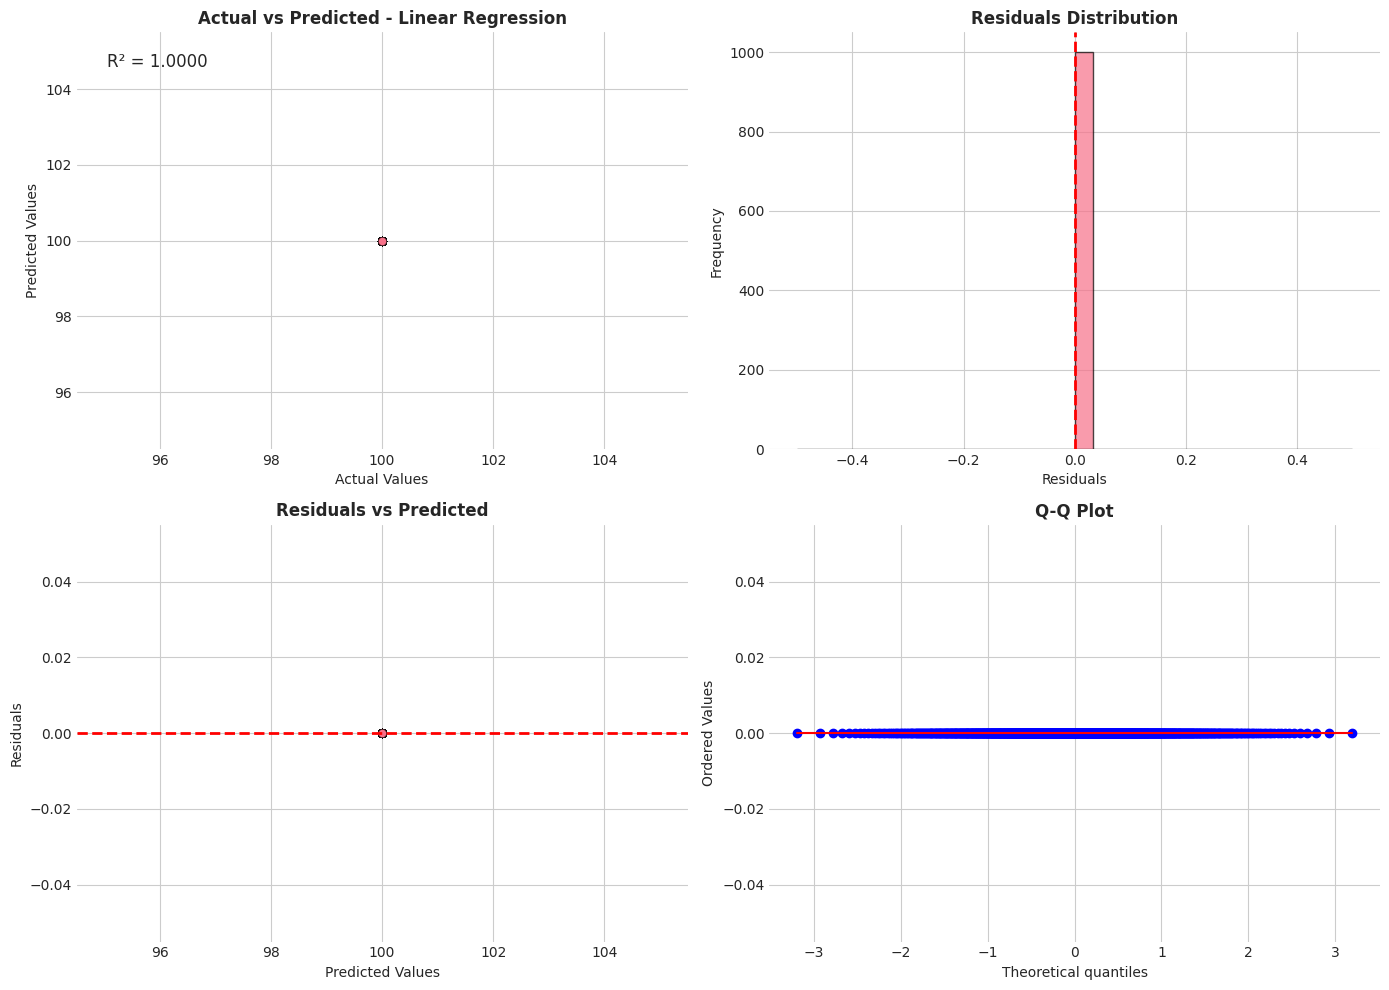

In [33]:

best_regressor_name = regression_df.iloc[0]['Model']
best_regressor = regression_models[best_regressor_name]
best_regressor.fit(X_train_reg_scaled, y_train_reg)
y_pred_best_reg = best_regressor.predict(X_test_reg_scaled)


print(f"DETAILED ANALYSIS - BEST REGRESSION MODEL: {best_regressor_name}")


# Residual analysis
residuals = y_test_reg - y_pred_best_reg

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted
axes[0, 0].scatter(y_test_reg, y_pred_best_reg, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Values')
axes[0, 0].set_ylabel('Predicted Values')
axes[0, 0].set_title(f'Actual vs Predicted - {best_regressor_name}', fontweight='bold')
axes[0, 0].text(0.05, 0.95, f'R² = {r2_score(y_test_reg, y_pred_best_reg):.4f}', 
                transform=axes[0, 0].transAxes, fontsize=12, verticalalignment='top')

# Residuals distribution
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Residuals Distribution', fontweight='bold')

# Residuals vs Predicted
axes[1, 0].scatter(y_pred_best_reg, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Values')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residuals vs Predicted', fontweight='bold')

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot', fontweight='bold')

plt.tight_layout()
plt.show()


#  FEATURE IMPORTANCE ANALYSIS

FEATURE IMPORTANCE ANALYSIS


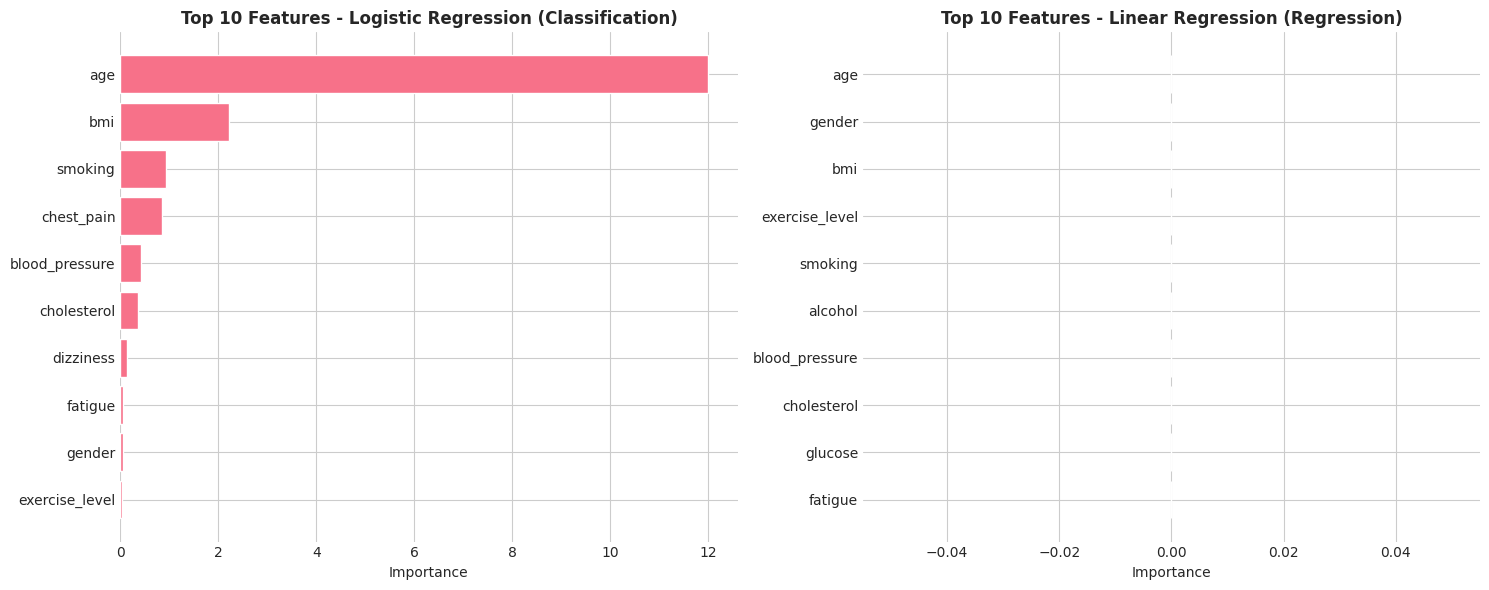


Top 5 Features for Classification:


,Feature,Importance
0,age,12.003186
2,bmi,2.225019
4,smoking,0.937949
10,chest_pain,0.859081
6,blood_pressure,0.418729



Top 5 Features for Regression:


,Feature,Importance
0,age,0.0
1,gender,0.0
2,bmi,0.0
3,exercise_level,0.0
4,smoking,0.0


In [34]:

print("FEATURE IMPORTANCE ANALYSIS")


# Get feature importance from best models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Classification feature importance
if hasattr(best_classifier, 'feature_importances_'):
    importances_clf = best_classifier.feature_importances_
elif hasattr(best_classifier, 'coef_'):
    importances_clf = np.abs(best_classifier.coef_[0])
else:
    # Use Random Forest as fallback
    temp_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    temp_rf.fit(X_train_scaled, y_train)
    importances_clf = temp_rf.feature_importances_

feature_importance_clf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_clf
}).sort_values('Importance', ascending=False)

axes[0].barh(feature_importance_clf['Feature'][:10], feature_importance_clf['Importance'][:10])
axes[0].set_xlabel('Importance')
axes[0].set_title(f'Top 10 Features - {best_classifier_name} (Classification)', fontweight='bold')
axes[0].invert_yaxis()

# Regression feature importance
if hasattr(best_regressor, 'feature_importances_'):
    importances_reg = best_regressor.feature_importances_
elif hasattr(best_regressor, 'coef_'):
    importances_reg = np.abs(best_regressor.coef_)
else:
    temp_rfr = RandomForestRegressor(n_estimators=100, random_state=42)
    temp_rfr.fit(X_train_reg_scaled, y_train_reg)
    importances_reg = temp_rfr.feature_importances_

feature_importance_reg = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_reg
}).sort_values('Importance', ascending=False)

axes[1].barh(feature_importance_reg['Feature'][:10], feature_importance_reg['Importance'][:10])
axes[1].set_xlabel('Importance')
axes[1].set_title(f'Top 10 Features - {best_regressor_name} (Regression)', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 5 Features for Classification:")
display(feature_importance_clf.head())
print("\nTop 5 Features for Regression:")
display(feature_importance_reg.head())

#  HYPERPARAMETER TUNING

In [35]:

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


print("HYPERPARAMETER TUNING - BEST MODELS")


# Tune best classifier
print(f"\nTuning {best_classifier_name}...")

if best_classifier_name == 'Random Forest':
    param_grid_clf = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
elif best_classifier_name == 'XGBoost':
    param_grid_clf = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 1.0]
    }
elif best_classifier_name == 'LightGBM':
    param_grid_clf = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1],
        'num_leaves': [31, 50]
    }
else:
    param_grid_clf = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10]
    }

try:
    grid_search_clf = GridSearchCV(best_classifier, param_grid_clf, cv=5, scoring='f1', n_jobs=-1)
    grid_search_clf.fit(X_train_scaled, y_train)
    
    print(f"Best parameters: {grid_search_clf.best_params_}")
    print(f"Best cross-validation F1: {grid_search_clf.best_score_:.4f}")
    
    # Evaluate tuned model
    y_pred_tuned = grid_search_clf.best_estimator_.predict(X_test_scaled)
    print(f"Test F1 after tuning: {f1_score(y_test, y_pred_tuned):.4f}")
    
except Exception as e:
    print(f"Tuning failed: {e}")

# Tune best regressor
print(f"\nTuning {best_regressor_name}...")

if best_regressor_name == 'Random Forest Regressor':
    param_grid_reg = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10]
    }
elif best_regressor_name == 'XGBoost Regressor':
    param_grid_reg = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3]
    }
else:
    param_grid_reg = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10]
    }

try:
    grid_search_reg = GridSearchCV(best_regressor, param_grid_reg, cv=5, scoring='r2', n_jobs=-1)
    grid_search_reg.fit(X_train_reg_scaled, y_train_reg)
    
    print(f"Best parameters: {grid_search_reg.best_params_}")
    print(f"Best cross-validation R²: {grid_search_reg.best_score_:.4f}")
    
    # Evaluate tuned model
    y_pred_tuned_reg = grid_search_reg.best_estimator_.predict(X_test_reg_scaled)
    print(f"Test R² after tuning: {r2_score(y_test_reg, y_pred_tuned_reg):.4f}")
    
except Exception as e:
    print(f"Tuning failed: {e}")

HYPERPARAMETER TUNING - BEST MODELS

Tuning Logistic Regression...
Tuning failed: Invalid parameter 'max_depth' for estimator LogisticRegression(max_iter=1000, random_state=42). Valid parameters are: ['C', 'class_weight', 'dual', 'fit_intercept', 'intercept_scaling', 'l1_ratio', 'max_iter', 'multi_class', 'n_jobs', 'penalty', 'random_state', 'solver', 'tol', 'verbose', 'warm_start'].

Tuning Linear Regression...
Tuning failed: Invalid parameter 'max_depth' for estimator LinearRegression(). Valid parameters are: ['copy_X', 'fit_intercept', 'n_jobs', 'positive'].




#  MODEL COMPARISON VISUALIZATIONS


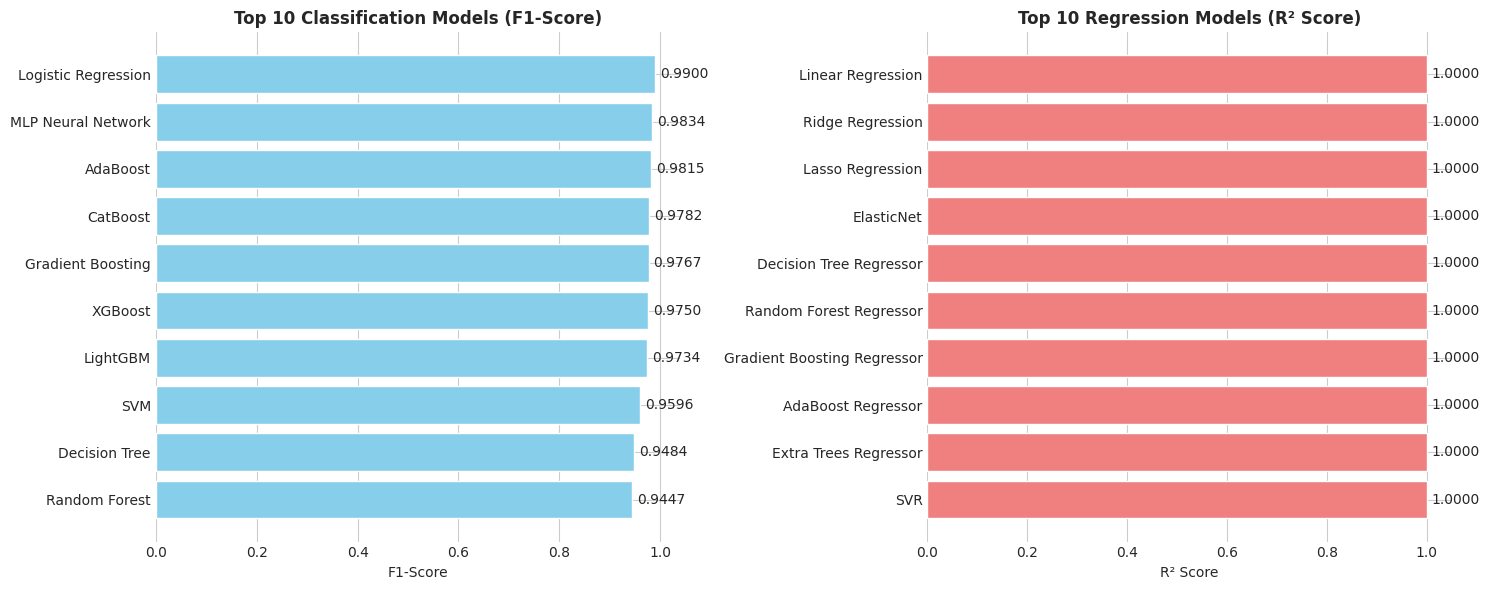

In [36]:


# Classification models comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot for top 10 classification models
top10_clf = classification_df.head(10)
axes[0].barh(top10_clf['Model'], top10_clf['F1-Score'], color='skyblue')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Top 10 Classification Models (F1-Score)', fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(top10_clf['F1-Score']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

# Regression models comparison
top10_reg = regression_df.head(10)
axes[1].barh(top10_reg['Model'], top10_reg['R² Score'], color='lightcoral')
axes[1].set_xlabel('R² Score')
axes[1].set_title('Top 10 Regression Models (R² Score)', fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(top10_reg['R² Score']):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

# LEARNING CURVES

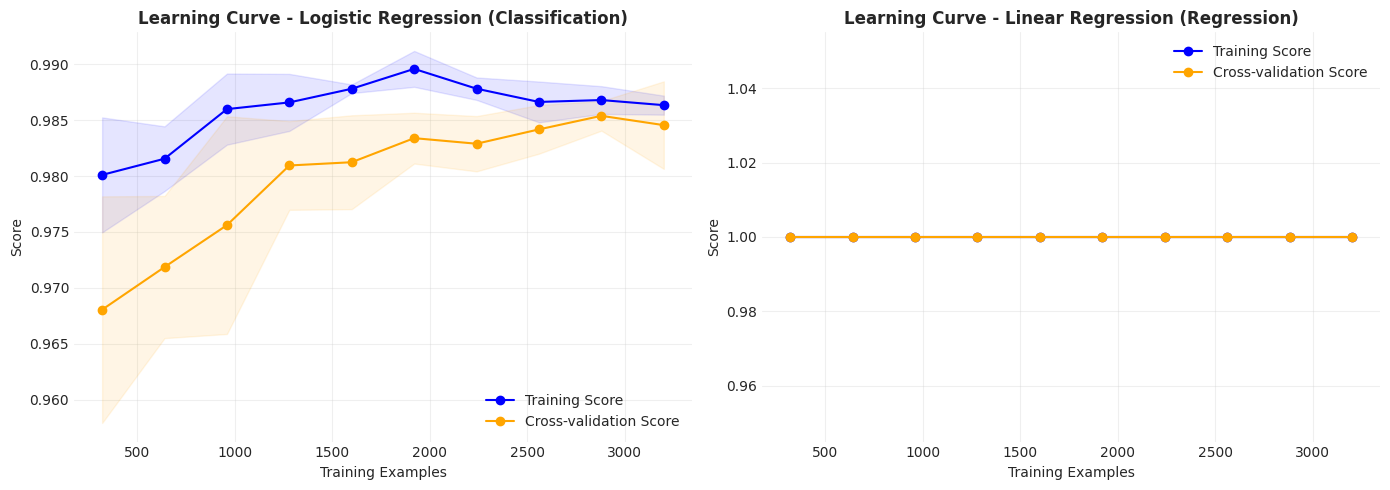

In [37]:

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title, ax):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1' if 'heart' in str(y) else 'r2'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    ax.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation Score')
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('Score')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curve for best classifier
plot_learning_curve(best_classifier, X_train_scaled, y_train, 
                   f'Learning Curve - {best_classifier_name} (Classification)', axes[0])

# Learning curve for best regressor
plot_learning_curve(best_regressor, X_train_reg_scaled, y_train_reg, 
                   f'Learning Curve - {best_regressor_name} (Regression)', axes[1])

plt.tight_layout()
plt.show()


#  PREDICTION ON NEW DATA 

In [38]:


print("PREDICTION DEMO - Sample New Data")


# Create sample new data
sample_data = pd.DataFrame({
    'age': [55, 42, 68],
    'gender': [1, 0, 1],  # 1=Male, 0=Female
    'bmi': [28.5, 22.3, 32.1],
    'exercise_level': [2, 3, 1],
    'smoking': [1, 0, 1],
    'alcohol': [1, 1, 0],
    'blood_pressure': [135, 118, 145],
    'cholesterol': [220, 180, 260],
    'glucose': [110, 95, 130],
    'fatigue': [1, 0, 1],
    'chest_pain': [0, 0, 1],
    'dizziness': [1, 0, 1]
})

# Scale sample data
sample_scaled = scaler_standard.transform(sample_data)

# Make predictions
heart_pred = best_classifier.predict(sample_scaled)
heart_proba = best_classifier.predict_proba(sample_scaled)[:, 1]
risk_pred = best_regressor.predict(sample_scaled)

# Display results
results_df = sample_data.copy()
results_df['Heart_Disease_Prediction'] = heart_pred
results_df['Heart_Disease_Probability'] = heart_proba
results_df['Health_Risk_Score_Prediction'] = risk_pred

print("\nPredictions for sample patients:")
display(results_df)

PREDICTION DEMO - Sample New Data

Predictions for sample patients:


,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,Heart_Disease_Prediction,Heart_Disease_Probability,Health_Risk_Score_Prediction
0,55,1,28.5,2,1,1,135,220,110,1,0,1,0,1.136901e-01,100.0
1,42,0,22.3,3,0,1,118,180,95,0,0,0,0,7.276445e-08,100.0
2,68,1,32.1,1,1,0,145,260,130,1,1,1,1,9.999691e-01,100.0


In [39]:


# ===== COLORS =====
RED = "\033[91m"
GREEN = "\033[92m"
YELLOW = "\033[93m"
BLUE = "\033[94m"
MAGENTA = "\033[95m" 
CYAN = "\033[96m"
WHITE = "\033[97m"   
BOLD = "\033[1m"
END = "\033[0m"

def box(text, color=CYAN):
    line = "═" * 70
    print(color + BOLD + "╔" + line + "╗")
    print("║" + text.center(70) + "║")
    print("╚" + line + "╝" + END)


# ================= TITLE =================
box("FINAL SUMMARY REPORT ", CYAN)


# ================= DATASET =================
box("DATASET INFORMATION ", YELLOW)
print(GREEN + f"• Total samples: {len(df)}")
print(GREEN + f"• Total features: {len(X.columns)}")
print(GREEN + "• Targets: Heart Disease, Diabetes, Stroke, Risk Score\n")


# ================= CLASSIFICATION =================
box("BEST CLASSIFICATION MODEL ", MAGENTA)
print(WHITE + f"• Model: {best_classifier_name}")
print(CYAN + f"• F1-Score: {classification_df.iloc[0]['F1-Score']:.4f}")
print(CYAN + f"• ROC-AUC: {classification_df.iloc[0]['ROC-AUC']:.4f}")
print(CYAN + f"• Accuracy: {classification_df.iloc[0]['Accuracy']:.4f}\n")


# ================= REGRESSION =================
box("BEST REGRESSION MODEL ", BLUE)
print(WHITE + f"• Model: {best_regressor_name}")
print(CYAN + f"• R² Score: {regression_df.iloc[0]['R² Score']:.4f}")
print(CYAN + f"• RMSE: {regression_df.iloc[0]['RMSE']:.4f}")
print(CYAN + f"• MAE: {regression_df.iloc[0]['MAE']:.4f}\n")


# ================= FEATURES =================
box("TOP FEATURES ", YELLOW)

print(GREEN + "Classification Features:")
for i, row in feature_importance_clf.head().iterrows():
    print(f"  {i+1}. {row['Feature']} -> {row['Importance']:.4f}")

print()

print(GREEN + "Regression Features:")
for i, row in feature_importance_reg.head().iterrows():
    print(f"  {i+1}. {row['Feature']} -> {row['Importance']:.4f}")


# ================= RECOMMENDATION =================
box("RECOMMENDATIONS ", BLUE)
print(WHITE + f"• Use {best_classifier_name} for classification")
print(WHITE + f"• Use {best_regressor_name} for regression")
print(WHITE + "• Do feature engineering on top features")
print(WHITE + "• Apply hyperparameter tuning for better results\n")




╔══════════════════════════════════════════════════════════════════════╗
║                        FINAL SUMMARY REPORT                          ║
╚══════════════════════════════════════════════════════════════════════╝
╔══════════════════════════════════════════════════════════════════════╗
║                         DATASET INFORMATION                          ║
╚══════════════════════════════════════════════════════════════════════╝
• Total samples: 5000
• Total features: 12
• Targets: Heart Disease, Diabetes, Stroke, Risk Score

╔══════════════════════════════════════════════════════════════════════╗
║                      BEST CLASSIFICATION MODEL                       ║
╚══════════════════════════════════════════════════════════════════════╝
• Model: Logistic Regression
• F1-Score: 0.9900
• ROC-AUC: 0.9998
• Accuracy: 0.9940

╔══════════════════════════════════════════════════════════════════════╗
║                        BEST REGRESSION MODEL                         ║
╚═══════════